In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Load data

In [14]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\24082025\processed_train.csv")
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\24082025\processed_test.csv")

In [3]:

df_test.columns

Index(['SEQN', 'Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'CreatinineUmol', 'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin',
       'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin',
       'RedCellDistributionWidth', 'PlateletCount', 'MeanPlateletVolume',
       'Hba1c', 'VitaminD', 'SmokeFam', 'milk_consumption', 'YearStart',
       'label'],
      dtype='object')

In [15]:
columns_remove = [
    'VitaminD',
    'YearStart',
]

In [5]:
df_train['SmokeFam'].value_counts()

SmokeFam
0    11585
1     4694
Name: count, dtype: int64

In [7]:
df_test['SmokeFam'].value_counts()

SmokeFam
1    2575
0    2070
Name: count, dtype: int64

In [8]:
df_test['Hba1c'].isna().sum()

np.int64(0)

In [16]:
df_train = df_train[df_train['milk_consumption']<=3]
df_test = df_test[df_test['milk_consumption']<=3]

In [17]:
df_train.drop(columns=columns_remove, inplace=True)
df_test.drop(columns=columns_remove, inplace=True)

In [18]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'Hba1c', 'SmokeFam',
       'milk_consumption', 'label'],
      dtype='object')

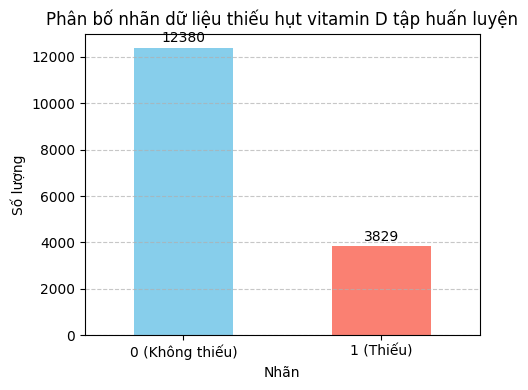

In [12]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_train['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Phân bố nhãn dữ liệu thiếu hụt vitamin D tập huấn luyện')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1], labels=['0 (Không thiếu)', '1 (Thiếu)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


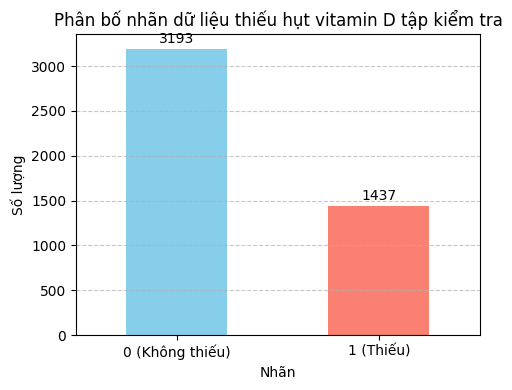

In [13]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_test['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Phân bố nhãn dữ liệu thiếu hụt vitamin D tập kiểm tra')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1], labels=['0 (Không thiếu)', '1 (Thiếu)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [19]:
category_columns = [
    'Gender','SmokeFam' ,'Race', 'label','milk_consumption'
]

# Model training and evaluation

In [20]:
unuseful_features = ['WaistCircumference','AST','ALT','AlkalinePhosphotase','UricAcid','LDLCholesterol','Hematocrit','MeanCellHemoglobin','PlateletCount', 'MeanPlateletVolume']

In [21]:
df_train.drop(columns=unuseful_features,inplace=True)
df_test = df_test[df_train.columns]

In [22]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI', 'FastingGlucose',
       'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin',
       'MeanCellVolumn', 'RedCellDistributionWidth', 'Hba1c', 'SmokeFam',
       'milk_consumption', 'label'],
      dtype='object')

# Opts 1:

['Age', 'PIR', 'BMI', 'FastingGlucose', 'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth', 'Hba1c']
['Gender', 'Race', 'milk_consumption', 'SmokeFam']
🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8086, R=0.7385, F1=0.7720, Support=3193
Class 1: P=0.5128, R=0.6117, F1=0.5579, Support=1437
✅ LightGBM - Accuracy: 0.6991, F1: 0.6649, AUC: 0.7330

🚀 Training: Naive Bayes


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Per-class metrics:
Class 0: P=0.8323, R=0.5346, F1=0.6510, Support=3193
Class 1: P=0.4238, R=0.7606, F1=0.5443, Support=1437
✅ Naive Bayes - Accuracy: 0.6048, F1: 0.5977, AUC: 0.7012

⚡ Creating Manual Ensembles...

🔬 Testing Multiple Mathematical Ensemble Formulations...

🔬 Testing Extensive Weight Combinations...
✅ 50-50 Equal - Accuracy: 0.6339, F1: 0.6225, AUC: 0.7287
✅ 60-40 LGBM-NB - Accuracy: 0.6447, F1: 0.6306, AUC: 0.7315
✅ 70-30 LGBM-NB - Accuracy: 0.6583, F1: 0.6402, AUC: 0.7339
✅ 80-20 LGBM-NB - Accuracy: 0.6726, F1: 0.6489, AUC: 0.7354
✅ 81-19 LGBM-NB - Accuracy: 0.6745, F1: 0.6504, AUC: 0.7355
✅ 82-18 LGBM-NB - Accuracy: 0.6771, F1: 0.6521, AUC: 0.7356
✅ 83-17 LGBM-NB - Accuracy: 0.6778, F1: 0.6525, AUC: 0.7356
✅ 84-16 LGBM-NB - Accuracy: 0.6795, F1: 0.6538, AUC: 0.7357
✅ 85-15 LGBM-NB - Accuracy: 0.6816, F1: 0.6557, AUC: 0.7356
✅ 86-14 LGBM-NB - Accuracy: 0.6823, F1: 0.6559, AUC: 0.7356
✅ 87-13 LGBM-NB - Accuracy: 0.6847, F1: 0.6577, AUC: 0.7356
✅ 88-12 LGBM-NB - Accurac

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_21320\1483004233.py:293: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()


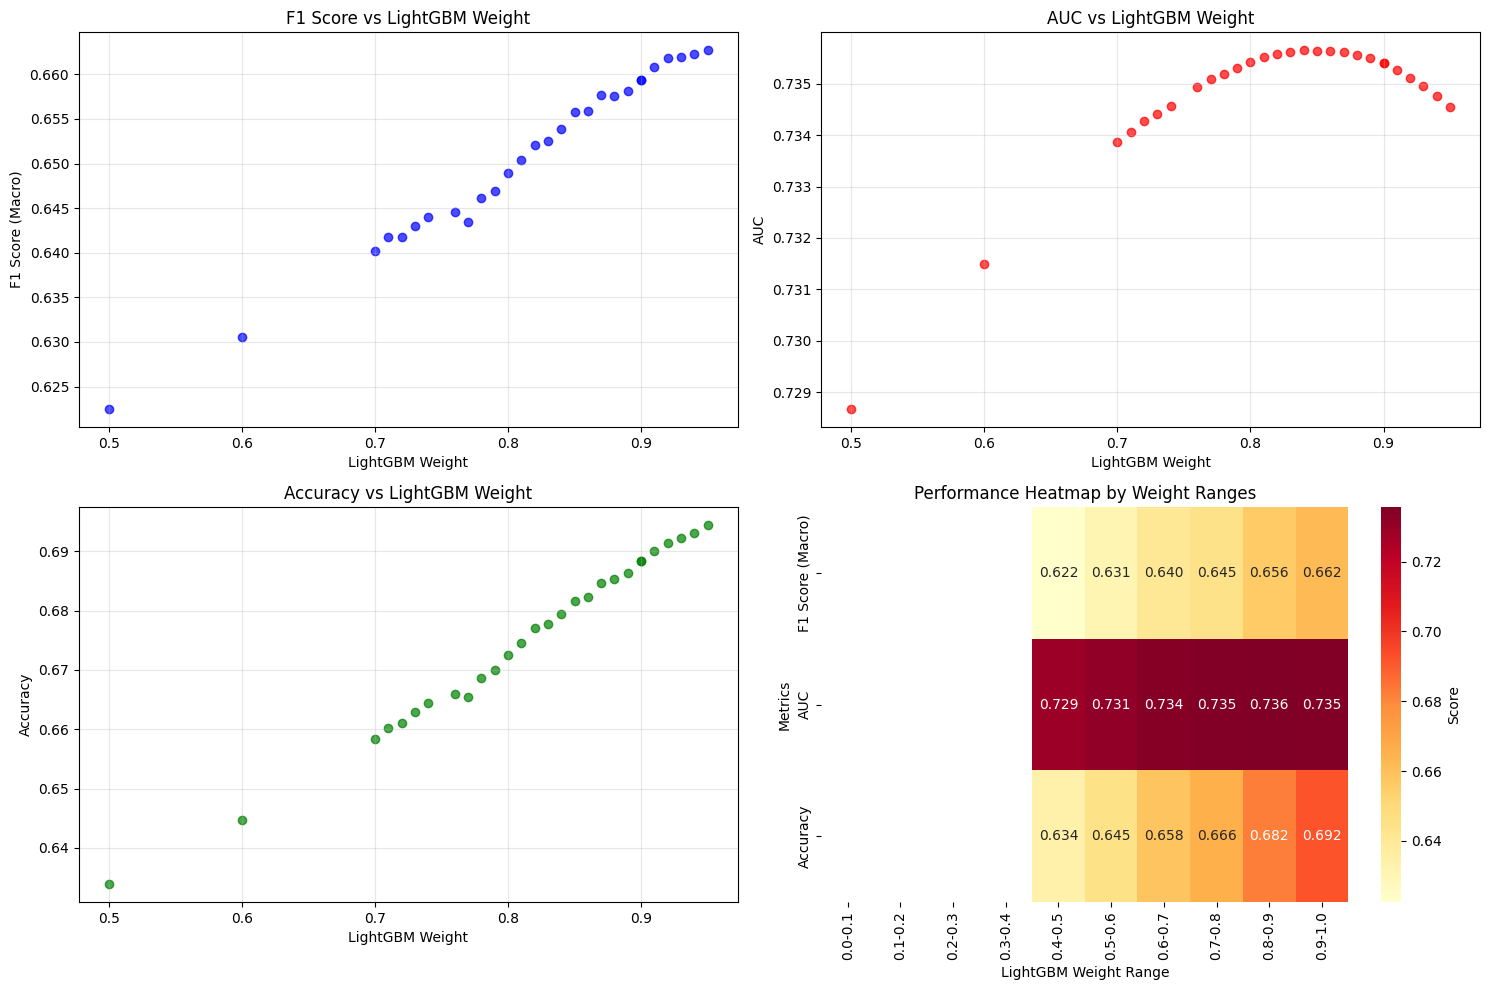


📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv

📊 FINAL RESULTS SUMMARY:
                 Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC  LGBM_Weight  NB_Weight
              LightGBM             0.6607          0.6751            0.6649    0.6991 0.7330          NaN        NaN
           Naive Bayes             0.6280          0.6476            0.5977    0.6048 0.7012          NaN        NaN
  Weighted 50-50 Equal             0.6400          0.6634            0.6225    0.6339 0.7287       0.5000     0.5000
Weighted 60-40 LGBM-NB             0.6425          0.6664            0.6306    0.6447 0.7315       0.6000     0.4000
Weighted 70-30 LGBM-NB             0.6459          0.6696            0.6402    0.6583 0.7339       0.7000     0.3000
Weighted 80-20 LGBM-NB             0.6489          0.6706            0.6489    0.6726 0.7354       0.8000     0.2000
Weighted 81-19 LGBM-NB             0.6500          0.6714            0.6504    0.6745 0.7355   

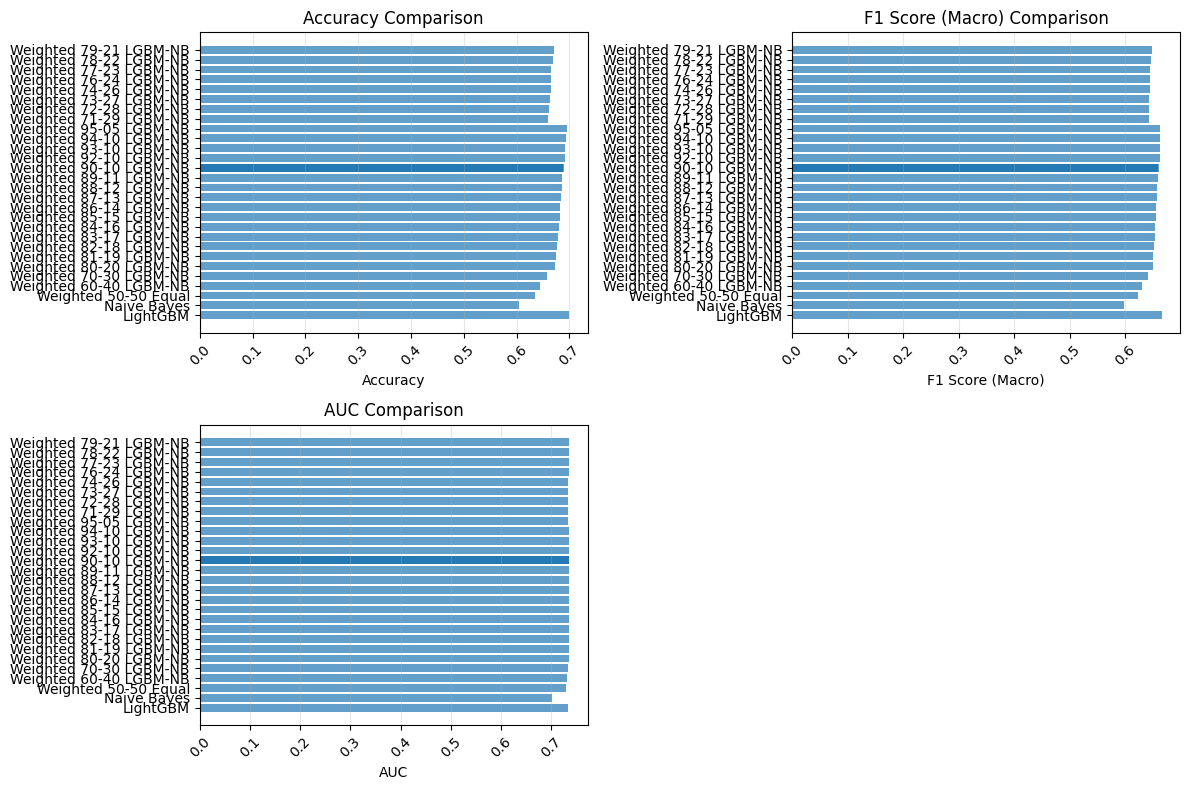


💡 Ensemble Tips:
- LightGBM typically handles complex patterns better
- Naive Bayes is fast and works well with small datasets
- Weighted average often performs better than equal weighting
- Test different weight combinations to find optimal balance


In [ ]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

X_train_raw = df_train.drop(columns='label')
y_train=df_train['label']
X_test_raw=df_test.drop(columns=['label'])
y_test=df_test['label']
categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']
print(numeric_cols)
print(categorical_cols)
# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])
from xgboost import XGBClassifier

xgb = XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    )

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

xgb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', xgb)
])
# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'Naive Bayes': nb_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        

        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")

        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    
    # 🧮 MATHEMATICAL ENSEMBLE COMBINATION THEORIES 🧮
    print("\n🔬 Testing Multiple Mathematical Ensemble Formulations...")
    
    ensemble_formulations = []
    
    # Comprehensive weight testing
    print("\n🔬 Testing Extensive Weight Combinations...")
    weight_combinations = [
        # Standard combinations
        (0.5, 0.5, "50-50 Equal"),
        (0.6, 0.4, "60-40 LGBM-NB"),
        (0.7, 0.3, "70-30 LGBM-NB"),
        (0.8, 0.2, "80-20 LGBM-NB"),
        (0.81, 0.19, "81-19 LGBM-NB"),
        (0.82, 0.18, "82-18 LGBM-NB"),
        (0.83, 0.17, "83-17 LGBM-NB"),
        (0.84, 0.16, "84-16 LGBM-NB"),
        (0.85, 0.15, "85-15 LGBM-NB"),
        (0.86, 0.14, "86-14 LGBM-NB"),
        (0.87, 0.13, "87-13 LGBM-NB"),
        (0.88, 0.12, "88-12 LGBM-NB"),
        (0.89, 0.11, "89-11 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.91, 0.09, "90-10 LGBM-NB"),
        (0.92, 0.08, "92-10 LGBM-NB"),
        (0.93, 0.07, "93-10 LGBM-NB"),
        (0.94, 0.06, "94-10 LGBM-NB"),
        (0.95, 0.05, "95-05 LGBM-NB"),


        # Very fine-grained around optimal range (70-80% LGBM)
        (0.71, 0.29, "71-29 LGBM-NB"),
        (0.72, 0.28, "72-28 LGBM-NB"),
        (0.73, 0.27, "73-27 LGBM-NB"),
        (0.74, 0.26, "74-26 LGBM-NB"),
        (0.76, 0.24, "76-24 LGBM-NB"),
        (0.77, 0.23, "77-23 LGBM-NB"),
        (0.78, 0.22, "78-22 LGBM-NB"),
        (0.79, 0.21, "79-21 LGBM-NB"),
    ]
    
    # Store results for analysis
    weight_results = []
    
    for w1, w2, desc in weight_combinations:
        ensemble_proba_test = w1 * lgbm_proba + w2 * nb_proba
        y_pred_test = (ensemble_proba_test > 0.5).astype(int)
        
        f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        accuracy_test = accuracy_score(y_test, y_pred_test)
        auc_test = roc_auc_score(y_test, ensemble_proba_test)
        precision_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
        recall_test = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
        
        result = {
            'Model': f'Weighted {desc}',
            'LGBM_Weight': w1,
            'NB_Weight': w2,
            'Precision (Macro)': precision_test,
            'Recall (Macro)': recall_test,
            'F1 Score (Macro)': f1_test,
            'Accuracy': accuracy_test,
            'AUC': auc_test
        }
        
        manual_results.append(result)
        weight_results.append(result)
        
        print(f"✅ {desc} - Accuracy: {accuracy_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
    
    # Find optimal weights
    weight_results_df = pd.DataFrame(weight_results)
    
    # Best by different metrics
    best_f1_weight = weight_results_df.loc[weight_results_df['F1 Score (Macro)'].idxmax()]
    best_auc_weight = weight_results_df.loc[weight_results_df['AUC'].idxmax()]
    best_acc_weight = weight_results_df.loc[weight_results_df['Accuracy'].idxmax()]
    
    print(f"\n🎯 OPTIMAL WEIGHTS:")
    print(f"Best F1: LGBM={best_f1_weight['LGBM_Weight']:.2f}, NB={best_f1_weight['NB_Weight']:.2f} (F1: {best_f1_weight['F1 Score (Macro)']:.4f})")
    print(f"Best AUC: LGBM={best_auc_weight['LGBM_Weight']:.2f}, NB={best_auc_weight['NB_Weight']:.2f} (AUC: {best_auc_weight['AUC']:.4f})")
    print(f"Best Accuracy: LGBM={best_acc_weight['LGBM_Weight']:.2f}, NB={best_acc_weight['NB_Weight']:.2f} (Acc: {best_acc_weight['Accuracy']:.4f})")
    
    # Plot weight analysis
    plt.figure(figsize=(15, 10))
    
    # F1 Score vs LGBM Weight
    plt.subplot(2, 2, 1)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['F1 Score (Macro)'], alpha=0.7, c='blue')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('F1 Score (Macro)')
    plt.title('F1 Score vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # AUC vs LGBM Weight  
    plt.subplot(2, 2, 2)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['AUC'], alpha=0.7, c='red')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('AUC')
    plt.title('AUC vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs LGBM Weight
    plt.subplot(2, 2, 3)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['Accuracy'], alpha=0.7, c='green')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Combined metrics heatmap
    plt.subplot(2, 2, 4)
    # Create a simplified heatmap with binned weights
    weight_bins = np.arange(0, 1.1, 0.1)
    binned_weights = pd.cut(weight_results_df['LGBM_Weight'], weight_bins, labels=[f'{i:.1f}-{i+0.1:.1f}' for i in weight_bins[:-1]])
    heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()
    
    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
    plt.title('Performance Heatmap by Weight Ranges')
    plt.xlabel('LightGBM Weight Range')
    plt.ylabel('Metrics')
    
    plt.tight_layout()
    plt.show()
    
    # Save detailed weight analysis
    weight_results_df.to_csv("weight_analysis_nb_lgbm.csv", index=False)
    print(f"\n📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("nb_lgbm_ensemble_results.csv", index=False)
print(f"\n✅ Results exported to: nb_lgbm_ensemble_results.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot model comparison ======
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
models = results_df['Model'].tolist()

# Create subplots for each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Filter out None values for AUC
    if metric == 'AUC':
        data = results_df[results_df[metric].notna()]
    else:
        data = results_df
    
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
    
    # Rotate labels if needed
    if len(models) > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Ensemble Tips:")
print("- LightGBM typically handles complex patterns better")
print("- Naive Bayes is fast and works well with small datasets")
print("- Weighted average often performs better than equal weighting")
print("- Test different weight combinations to find optimal balance")

# Opts 2:

In [103]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8086, R=0.7385, F1=0.7720, Support=3193
Class 1: P=0.5128, R=0.6117, F1=0.5579, Support=1437
✅ LightGBM - Accuracy: 0.6991, F1: 0.6649, AUC: 0.7330

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Threshold Ensemble - Accuracy: 0.6724, F1: 0.6519
✅ Weighted Average - Accuracy: 0.6903, F1: 0.6614, AUC: 0.7366
✅ Hybrid Rules - Accuracy: 0.7171, F1: 0.6669

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6607          0.6751            0.6649    0.6991 0.7330
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6540          0.6779            0.6519    0.6724    NaN
  Weighted Average             0.6581          0.6769            0.6614    0.6903 0.7366
      Hybrid Rules             0.6683          0.6657            0.6669    0.7171    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Hybrid Rules (F1 Score: 0.6669)


🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM - Accuracy: 0.6991, F1: 0.6649, AUC: 0.7330

🚀 Training: Naive Bayes
✅ Naive Bayes - Accuracy: 0.6048, F1: 0.5977, AUC: 0.7012

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Weighted Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LGBM-NB-TabNet 40-30-30 - Accuracy: 0.6512, F1: 0.6373, AUC: 0.7334
✅ LGBM-NB-TabNet 50-25-25 - Accuracy: 0.6590, F1: 0.6424, AUC: 0.7355
✅ Equal Weights - Accuracy: 0.6456, F1: 0.6332, AUC: 0.7316

📊 Results exported to 'ensemble_results_nb_lgbm_tabnet.csv'

🏆 BEST MODEL: LightGBM (F1 Score: 0.6649)


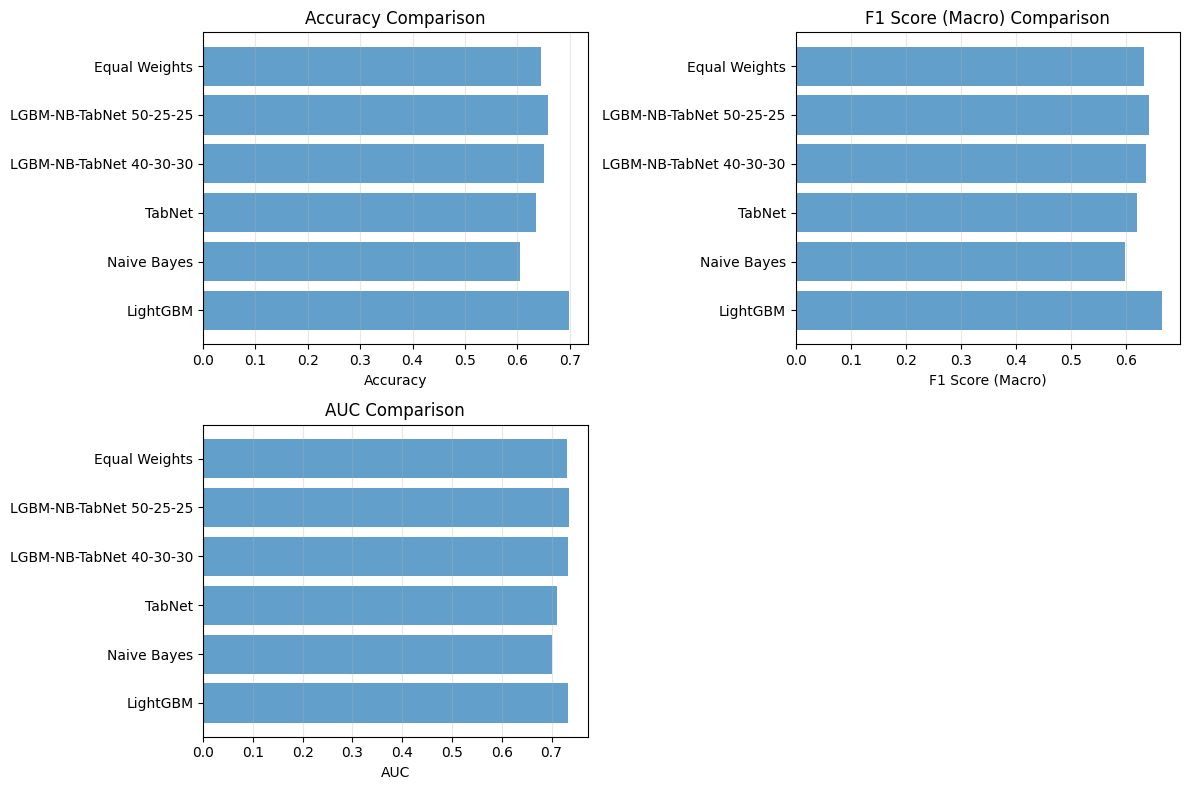

In [17]:
# ====== IMPORTS ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ====== 0) Dataset preparation ======
# X_train_raw, X_test_raw, y_train, y_test should be prepared
# categorical_cols and numeric_cols should be defined

X_train_raw = df_train.drop(columns='label')
y_train = df_train['label']
X_test_raw = df_test.drop(columns='label')
y_test = df_test['label']

categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col != 'label']

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)
lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()
preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)
nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])

# ====== 3) TabNet pipeline ======
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

smotenc = SMOTENC(categorical_features=cat_idxs, random_state=42, sampling_strategy='auto')

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.5,
    cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=3,
    n_independent=2, n_shared=2, momentum=0.02,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42, verbose=0
)

def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 4) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 5) Train individual models ======
individual_models = {
    'LightGBM': lgbm_wrapped,
    'Naive Bayes': nb_wrapped,
    'TabNet': tabnet_wrapped
}

individual_results = []

print("🔥 Training Individual Models...")
for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    model.fit(X_train_raw, y_train)
    y_pred = model.predict(X_test_raw)
    y_proba = model.predict_proba(X_test_raw)
    
    auc = roc_auc_score(y_test, y_proba[:, 1]) if len(np.unique(y_test))==2 else roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    individual_results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })
    print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

# ====== 6) Manual weighted ensemble (LGBM + NB + TabNet) ======
print("\n⚡ Creating Manual Weighted Ensembles...")

lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]

weight_combinations = [
    (0.4, 0.3, 0.3, "LGBM-NB-TabNet 40-30-30"),
    (0.5, 0.25, 0.25, "LGBM-NB-TabNet 50-25-25"),
    (0.33, 0.33, 0.34, "Equal Weights")
]

manual_results = []

for w_lgbm, w_nb, w_tab, desc in weight_combinations:
    ensemble_proba = w_lgbm*lgbm_proba + w_nb*nb_proba + w_tab*tabnet_proba
    y_pred_ensemble = (ensemble_proba > 0.5).astype(int)
    
    f1_score_macro = f1_score(y_test, y_pred_ensemble, average='macro', zero_division=0)
    acc = accuracy_score(y_test, y_pred_ensemble)
    auc = roc_auc_score(y_test, ensemble_proba)
    precision = precision_score(y_test, y_pred_ensemble, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred_ensemble, average='macro', zero_division=0)
    
    manual_results.append({
        'Model': desc,
        'LGBM_Weight': w_lgbm,
        'NB_Weight': w_nb,
        'TabNet_Weight': w_tab,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1_score_macro,
        'Accuracy': acc,
        'AUC': auc
    })
    print(f"✅ {desc} - Accuracy: {acc:.4f}, F1: {f1_score_macro:.4f}, AUC: {auc:.4f}")

# ====== 7) Compile & Save Results ======
all_results = individual_results + manual_results
results_df = pd.DataFrame(all_results)
results_df.to_csv("ensemble_results_nb_lgbm_tabnet.csv", index=False)
print("\n📊 Results exported to 'ensemble_results_nb_lgbm_tabnet.csv'")

# Best model
best_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1 Score (Macro)']
print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot comparison ======
plt.figure(figsize=(12,8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    data = results_df[results_df[metric].notna()]
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [104]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.7
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport07.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Per-class metrics:
Class 0: P=0.8086, R=0.7385, F1=0.7720, Support=3193
Class 1: P=0.5128, R=0.6117, F1=0.5579, Support=1437
✅ LightGBM - Accuracy: 0.6991, F1: 0.6649, AUC: 0.7330

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Threshold Ensemble - Accuracy: 0.6920, F1: 0.6635
✅ Weighted Average - Accuracy: 0.6903, F1: 0.6614, AUC: 0.7366
✅ Hybrid Rules - Accuracy: 0.7171, F1: 0.6669

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6607          0.6751            0.6649    0.6991 0.7330
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6601          0.6793            0.6635    0.6920    NaN
  Weighted Average             0.6581          0.6769            0.6614    0.6903 0.7366
      Hybrid Rules             0.6683          0.6657            0.6669    0.7171    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Hybrid Rules (F1 Score: 0.6669)


In [106]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.7
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm200_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport07.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Per-class metrics:
Class 0: P=0.7948, R=0.7701, F1=0.7822, Support=3193
Class 1: P=0.5221, R=0.5581, F1=0.5395, Support=1437
✅ LightGBM - Accuracy: 0.7043, F1: 0.6609, AUC: 0.7277

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Threshold Ensemble - Accuracy: 0.6985, F1: 0.6643
✅ Weighted Average - Accuracy: 0.6976, F1: 0.6641, AUC: 0.7336
✅ Hybrid Rules - Accuracy: 0.7216, F1: 0.6673

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6584          0.6641            0.6609    0.7043 0.7277
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6601          0.6744            0.6643    0.6985    NaN
  Weighted Average             0.6600          0.6750            0.6641    0.6976 0.7336
      Hybrid Rules             0.6719          0.6638            0.6673    0.7216    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Hybrid Rules (F1 Score: 0.6673)


In [107]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.8, 0.2
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport8020.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8086, R=0.7385, F1=0.7720, Support=3193
Class 1: P=0.5128, R=0.6117, F1=0.5579, Support=1437
✅ LightGBM - Accuracy: 0.6991, F1: 0.6649, AUC: 0.7330

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Threshold Ensemble - Accuracy: 0.6724, F1: 0.6519
✅ Weighted Average - Accuracy: 0.6940, F1: 0.6635, AUC: 0.7364
✅ Hybrid Rules - Accuracy: 0.7171, F1: 0.6669

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6607          0.6751            0.6649    0.6991 0.7330
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6540          0.6779            0.6519    0.6724    NaN
  Weighted Average             0.6597          0.6773            0.6635    0.6940 0.7364
      Hybrid Rules             0.6683          0.6657            0.6669    0.7171    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Hybrid Rules (F1 Score: 0.6669)


In [108]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.8, 0.2
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("xgboost_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport8020.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:56:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Per-class metrics:
Class 0: P=0.8212, R=0.6878, F1=0.7486, Support=3193
Class 1: P=0.4903, R=0.6674, F1=0.5653, Support=1437
✅ LightGBM - Accuracy: 0.6814, F1: 0.6569, AUC: 0.7372

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6585, F1: 0.6428
✅ Weighted Average - Accuracy: 0.6803, F1: 0.6581, AUC: 0.7400
✅ Hybrid Rules - Accuracy: 0.7162, F1: 0.6715

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6558          0.6776            0.6569    0.6814 0.7372
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6510          0.6761            0.6428    0.6585    NaN
  Weighted Average             0.6582          0.6816            0.6581    0.6803 0.7400
      Hybrid Rules             0.6701          0.6731            0.6715    0.7162    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE

In [ ]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import precision_recall_fscore_support
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.7
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.8, 0.2
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("xgboost_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport8020.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:33:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


❌ Error training LightGBM: name 'precision_recall_fscore_support' is not defined

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


KeyboardInterrupt: 

In [109]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.6, 0.4
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport8020.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8086, R=0.7385, F1=0.7720, Support=3193
Class 1: P=0.5128, R=0.6117, F1=0.5579, Support=1437
✅ LightGBM - Accuracy: 0.6991, F1: 0.6649, AUC: 0.7330

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Threshold Ensemble - Accuracy: 0.6724, F1: 0.6519
✅ Weighted Average - Accuracy: 0.6873, F1: 0.6609, AUC: 0.7356
✅ Hybrid Rules - Accuracy: 0.7171, F1: 0.6669

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6607          0.6751            0.6649    0.6991 0.7330
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6540          0.6779            0.6519    0.6724    NaN
  Weighted Average             0.6585          0.6793            0.6609    0.6873 0.7356
      Hybrid Rules             0.6683          0.6657            0.6669    0.7171    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Hybrid Rules (F1 Score: 0.6669)


In [19]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

import torch
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import precision_recall_fscore_support
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import StratifiedKFold
import time

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

print("🔥 Starting Comprehensive Parameter Grid Search...")
print("="*80)

# ====== 1) XGBoost Parameter Grid ======
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

# ====== 2) TabNet Parameter Grid ======
tabnet_param_grid = {
    'n_d': [16, 32, 64],
    'n_a': [16, 32, 64], 
    'n_steps': [3, 5, 7],
    'gamma': [1.0, 1.5, 2.0],
    'n_independent': [2, 3],
    'n_shared': [2, 3],
    'momentum': [0.02, 0.05, 0.1],
    'lr': [0.005, 0.01, 0.02],
    'step_size': [10, 20, 30],
    'gamma_scheduler': [0.8, 0.9, 0.95]
}

# ====== 3) Preprocessing setup ======
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# Calculate categorical dimensions and indices for TabNet
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

# ====== 4) Grid Search Functions ======
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Evaluate a model and return metrics"""
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        return {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy,
            'auc': auc
        }
    except Exception as e:
        print(f"Error in evaluation: {str(e)}")
        return None

def xgb_grid_search(param_grid, X_train, X_test, y_train, y_test, top_k=10):
    """Perform grid search for XGBoost"""
    print("\n🚀 Starting XGBoost Grid Search...")
    print(f"Total combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
    
    results = []
    param_combinations = list(product(*param_grid.values()))
    
    for i, params in enumerate(param_combinations):
        param_dict = dict(zip(param_grid.keys(), params))
        
        if i % 20 == 0:
            print(f"Progress: {i+1}/{len(param_combinations)} ({(i+1)/len(param_combinations)*100:.1f}%)")
        
        try:
            # Create XGBoost classifier
            xgb_clf = XGBClassifier(
                random_state=42,
                verbose=0,
                **param_dict
            )
            
            # Create pipeline
            xgb_pipe = ImbPipeline(steps=[
                ('preprocessor', preprocessor_xgb),
                ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
                ('classifier', xgb_clf)
            ])
            
            # Evaluate
            start_time = time.time()
            metrics = evaluate_model(xgb_pipe, X_train_raw, X_test_raw, y_train, y_test)
            train_time = time.time() - start_time
            
            if metrics:
                result = {
                    'model': 'XGBoost',
                    'params': param_dict,
                    'train_time': train_time,
                    **metrics
                }
                results.append(result)
            
        except Exception as e:
            print(f"Error with params {param_dict}: {str(e)}")
            continue
    
    # Sort by F1 score and return top k
    results.sort(key=lambda x: x['f1'], reverse=True)
    return results[:top_k]

def tabnet_grid_search(param_grid, X_train, X_test, y_train, y_test, top_k=10):
    """Perform grid search for TabNet"""
    print("\n🚀 Starting TabNet Grid Search...")
    print(f"Total combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
    
    results = []
    
    # Create smaller grid for TabNet due to longer training times
    # Sample random combinations instead of full grid
    n_combinations = min(200, np.prod([len(v) for v in param_grid.values()]))
    
    print(f"Sampling {n_combinations} random combinations for TabNet...")
    
    for i in range(n_combinations):
        # Sample random parameters
        param_dict = {}
        for key, values in param_grid.items():
            param_dict[key] = np.random.choice(values)
        
        if i % 10 == 0:
            print(f"Progress: {i+1}/{n_combinations} ({(i+1)/n_combinations*100:.1f}%)")
        
        try:
            # Create TabNet classifier
            tabnet_clf = TabNetClassifier(
                cat_idxs=cat_idxs,
                cat_dims=cat_dims,
                cat_emb_dim=3,
                optimizer_fn=torch.optim.Adam,
                optimizer_params=dict(lr=param_dict.pop('lr')),
                scheduler_params={
                    "step_size": param_dict.pop('step_size'), 
                    "gamma": param_dict.pop('gamma_scheduler')
                },
                scheduler_fn=torch.optim.lr_scheduler.StepLR,
                seed=42,
                verbose=0,
                **param_dict
            )
            
            # SMOTENC for mixed data types
            smotenc = SMOTENC(
                categorical_features=cat_idxs,
                sampling_strategy='auto',
                random_state=42
            )
            
            # Create pipeline
            tabnet_pipe = ImbPipeline(steps=[
                ('preprocessor_tabnet', preprocessor_tabnet),
                ('smotenc', smotenc),
                ('to_float32', float32_transformer),
                ('classifier', tabnet_clf)
            ])
            
            # Evaluate
            start_time = time.time()
            metrics = evaluate_model(tabnet_pipe, X_train_raw, X_test_raw, y_train, y_test)
            train_time = time.time() - start_time
            
            if metrics:
                result = {
                    'model': 'TabNet',
                    'params': param_dict,
                    'train_time': train_time,
                    **metrics
                }
                results.append(result)
            
        except Exception as e:
            print(f"Error with params {param_dict}: {str(e)}")
            continue
    
    # Sort by F1 score and return top k
    results.sort(key=lambda x: x['f1'], reverse=True)
    return results[:top_k]

# ====== 5) Execute Grid Searches ======
print("Starting comprehensive hyperparameter tuning...")

# XGBoost Grid Search
xgb_results = xgb_grid_search(xgb_param_grid, X_train_raw, X_test_raw, y_train, y_test, top_k=15)

# TabNet Grid Search  
tabnet_results = tabnet_grid_search(tabnet_param_grid, X_train_raw, X_test_raw, y_train, y_test, top_k=15)

# ====== 6) Results Analysis ======
def display_results(results, model_name):
    print(f"\n🏆 TOP {len(results)} {model_name} CONFIGURATIONS:")
    print("="*100)
    
    for i, result in enumerate(results, 1):
        print(f"\nRank {i}:")
        print(f"F1: {result['f1']:.4f} | Accuracy: {result['accuracy']:.4f} | AUC: {result['auc']:.4f} | Time: {result['train_time']:.2f}s")
        print(f"Precision: {result['precision']:.4f} | Recall: {result['recall']:.4f}")
        print(f"Parameters: {result['params']}")
        print("-" * 80)

# Display results
if xgb_results:
    display_results(xgb_results, "XGBoost")

if tabnet_results:
    display_results(tabnet_results, "TabNet")

# ====== 7) Train Best Models and Create Ensemble ======
print("\n⚡ Training Best Models for Ensemble...")

best_models = {}
ensemble_results = []

if xgb_results:
    # Train best XGBoost
    best_xgb_params = xgb_results[0]['params']
    print(f"Training best XGBoost with params: {best_xgb_params}")
    
    best_xgb = XGBClassifier(random_state=42, verbose=0, **best_xgb_params)
    best_xgb_pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor_xgb),
        ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier', best_xgb)
    ])
    
    best_xgb_pipe.fit(X_train_raw, y_train)
    best_models['XGBoost'] = best_xgb_pipe
    
    # Evaluate best XGBoost
    xgb_metrics = evaluate_model(best_xgb_pipe, X_train_raw, X_test_raw, y_train, y_test)
    ensemble_results.append({
        'Model': 'Best XGBoost',
        'Precision (Macro)': xgb_metrics['precision'],
        'Recall (Macro)': xgb_metrics['recall'],
        'F1 Score (Macro)': xgb_metrics['f1'],
        'Accuracy': xgb_metrics['accuracy'],
        'AUC': xgb_metrics['auc']
    })

if tabnet_results:
    # Train best TabNet
    best_tabnet_params = tabnet_results[0]['params']
    print(f"Training best TabNet with params: {best_tabnet_params}")
    
    # Recreate TabNet with best params
    best_tabnet = TabNetClassifier(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=0.01),  # Default if not in params
        scheduler_params={"step_size": 10, "gamma": 0.9},  # Default if not in params
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        seed=42,
        verbose=0,
        **best_tabnet_params
    )
    
    smotenc_best = SMOTENC(
        categorical_features=cat_idxs,
        sampling_strategy='auto',
        random_state=42
    )
    
    best_tabnet_pipe = ImbPipeline(steps=[
        ('preprocessor_tabnet', preprocessor_tabnet),
        ('smotenc', smotenc_best),
        ('to_float32', float32_transformer),
        ('classifier', best_tabnet)
    ])
    
    best_tabnet_pipe.fit(X_train_raw, y_train)
    best_models['TabNet'] = best_tabnet_pipe
    
    # Evaluate best TabNet
    tabnet_metrics = evaluate_model(best_tabnet_pipe, X_train_raw, X_test_raw, y_train, y_test)
    ensemble_results.append({
        'Model': 'Best TabNet',
        'Precision (Macro)': tabnet_metrics['precision'],
        'Recall (Macro)': tabnet_metrics['recall'],
        'F1 Score (Macro)': tabnet_metrics['f1'],
        'Accuracy': tabnet_metrics['accuracy'],
        'AUC': tabnet_metrics['auc']
    })

# ====== 8) Ensemble Methods ======
if len(best_models) == 2:
    print("\n🎯 Creating Ensemble Methods...")
    
    # Get predictions from best models
    xgb_proba = best_models['XGBoost'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = best_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    # Weighted Average Ensemble (multiple weights)
    weight_combinations = [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2)]
    
    for w1, w2 in weight_combinations:
        ensemble_proba = w1 * xgb_proba + w2 * tabnet_proba
        y_pred_ensemble = (ensemble_proba > 0.5).astype(int)
        
        metrics = {
            'precision': precision_score(y_test, y_pred_ensemble, average='macro', zero_division=0),
            'recall': recall_score(y_test, y_pred_ensemble, average='macro', zero_division=0),
            'f1': f1_score(y_test, y_pred_ensemble, average='macro', zero_division=0),
            'accuracy': accuracy_score(y_test, y_pred_ensemble),
            'auc': roc_auc_score(y_test, ensemble_proba)
        }
        
        ensemble_results.append({
            'Model': f'Weighted Ensemble ({w1:.1f}, {w2:.1f})',
            'Precision (Macro)': metrics['precision'],
            'Recall (Macro)': metrics['recall'],
            'F1 Score (Macro)': metrics['f1'],
            'Accuracy': metrics['accuracy'],
            'AUC': metrics['auc']
        })

# ====== 9) Final Results ======
final_df = pd.DataFrame(ensemble_results)

print("\n📊 FINAL COMPREHENSIVE RESULTS:")
print("="*100)
print(final_df.to_string(index=False, float_format='%.4f'))

# Save detailed results
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

# Save XGBoost results
if xgb_results:
    xgb_df = pd.DataFrame(xgb_results)
    xgb_df.to_csv(f"xgboost_grid_search_results_{timestamp}.csv", index=False)
    print(f"\n✅ XGBoost detailed results saved to: xgboost_grid_search_results_{timestamp}.csv")

# Save TabNet results  
if tabnet_results:
    tabnet_df = pd.DataFrame(tabnet_results)
    tabnet_df.to_csv(f"tabnet_grid_search_results_{timestamp}.csv", index=False)
    print(f"✅ TabNet detailed results saved to: tabnet_grid_search_results_{timestamp}.csv")

# Save final ensemble results
final_df.to_csv(f"ensemble_final_results_{timestamp}.csv", index=False)
print(f"✅ Final ensemble results saved to: ensemble_final_results_{timestamp}.csv")

# Best overall model
best_f1_idx = final_df['F1 Score (Macro)'].idxmax()
best_model = final_df.loc[best_f1_idx, 'Model']
best_f1 = final_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST OVERALL MODEL: {best_model} (F1 Score: {best_f1:.4f})")
print("="*100)

🔥 Starting Comprehensive Parameter Grid Search...
Starting comprehensive hyperparameter tuning...

🚀 Starting XGBoost Grid Search...
Total combinations to test: 3888
Progress: 1/3888 (0.0%)
Progress: 21/3888 (0.5%)
Progress: 41/3888 (1.1%)
Progress: 61/3888 (1.6%)
Progress: 81/3888 (2.1%)
Progress: 101/3888 (2.6%)
Progress: 121/3888 (3.1%)
Progress: 141/3888 (3.6%)
Progress: 161/3888 (4.1%)
Progress: 181/3888 (4.7%)
Progress: 201/3888 (5.2%)
Progress: 221/3888 (5.7%)
Progress: 241/3888 (6.2%)
Progress: 261/3888 (6.7%)
Progress: 281/3888 (7.2%)
Progress: 301/3888 (7.7%)
Progress: 321/3888 (8.3%)
Progress: 341/3888 (8.8%)
Progress: 361/3888 (9.3%)
Progress: 381/3888 (9.8%)
Progress: 401/3888 (10.3%)
Progress: 421/3888 (10.8%)
Progress: 441/3888 (11.3%)
Progress: 461/3888 (11.9%)
Progress: 481/3888 (12.4%)
Progress: 501/3888 (12.9%)
Progress: 521/3888 (13.4%)
Progress: 541/3888 (13.9%)
Progress: 561/3888 (14.4%)
Progress: 581/3888 (14.9%)
Progress: 601/3888 (15.5%)
Progress: 621/3888 (16.

KeyboardInterrupt: 

In [20]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import precision_recall_fscore_support

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC, BorderlineSMOTE, SVMSMOTE, ADASYN

# ========== 0) Assume dataset split ==========
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) Helper: TabNet preprocessing ======
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

def to_float32(X):
    return X.astype(np.float32)
float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# ====== 2) Helper: LightGBM preprocessing ======
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbosity=0
)

# ====== 3) Wrapper for imblearn pipeline compatibility ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# ====== 4) SMOTE strategies dictionary ======
smote_strategies = {
    'SMOTE': SMOTE(random_state=42, sampling_strategy='minority'),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42, sampling_strategy='minority'),
    'SVMSMOTE': SVMSMOTE(random_state=42, sampling_strategy='minority'),
    'ADASYN': ADASYN(random_state=42, sampling_strategy='minority'),
    'SMOTENC': SMOTENC(categorical_features=cat_idxs, random_state=42, sampling_strategy='auto')
}

# ====== 5) Loop over SMOTE strategies ======
all_results = []

for smote_name, smote_obj in smote_strategies.items():
    print(f"\n🔥 Training with SMOTE strategy: {smote_name}")

    # LightGBM pipeline
    lgbm_pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor_lgbm),
        ('smote', smote_obj if smote_name != 'SMOTENC' else SMOTE(random_state=42)),  # SMOTENC only for TabNet
        ('classifier', lgbm_clf)
    ])
    lgbm_wrapped = ImblearnWrapper(lgbm_pipe)

    # TabNet pipeline
    tabnet_pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor_tabnet),
        ('smote', smote_obj),
        ('to_float32', float32_transformer),
        ('classifier', tabnet_clf)
    ])
    tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

    models = {'LightGBM': lgbm_wrapped, 'TabNet': tabnet_wrapped}

    # Train and evaluate individual models
    individual_results = []
    for name, model in models.items():
        print(f"\n🚀 Training: {name}")
        try:
            model.fit(X_train_raw, y_train)
            y_pred = model.predict(X_test_raw)
            y_proba = model.predict_proba(X_test_raw)

            if len(np.unique(y_test)) == 2:
                auc = roc_auc_score(y_test, y_proba[:, 1])
            else:
                auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

            precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            accuracy = accuracy_score(y_test, y_pred)

            individual_results.append({
                'SMOTE Strategy': smote_name,
                'Model': name,
                'Precision (Macro)': precision,
                'Recall (Macro)': recall,
                'F1 Score (Macro)': f1,
                'Accuracy': accuracy,
                'AUC': auc
            })
            print(f"✅ {name} done. F1: {f1:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
        except Exception as e:
            print(f"❌ Error training {name}: {str(e)}")
    
    all_results.extend(individual_results)

# ====== 6) Compile results ======
results_df = pd.DataFrame(all_results)
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("ensemble_smote_strategies_results.csv", index=False)
print(f"\n✅ Results exported to CSV.")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_smote = results_df.loc[best_f1_idx, 'SMOTE Strategy']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']
print(f"\n🏆 BEST MODEL: {best_model} with {best_smote} (F1 Score: {best_f1:.4f})")



🔥 Training with SMOTE strategy: SMOTE

🚀 Training: LightGBM
✅ LightGBM done. F1: 0.6557, Accuracy: 0.6920, AUC: 0.7265

🚀 Training: TabNet
✅ TabNet done. F1: 0.5993, Accuracy: 0.6110, AUC: 0.6948

🔥 Training with SMOTE strategy: BorderlineSMOTE

🚀 Training: LightGBM
✅ LightGBM done. F1: 0.6516, Accuracy: 0.6847, AUC: 0.7236

🚀 Training: TabNet
✅ TabNet done. F1: 0.6084, Accuracy: 0.6171, AUC: 0.7102

🔥 Training with SMOTE strategy: SVMSMOTE

🚀 Training: LightGBM
✅ LightGBM done. F1: 0.6531, Accuracy: 0.6810, AUC: 0.7372

🚀 Training: TabNet
✅ TabNet done. F1: 0.6024, Accuracy: 0.6127, AUC: 0.7013

🔥 Training with SMOTE strategy: ADASYN

🚀 Training: LightGBM
✅ LightGBM done. F1: 0.6546, Accuracy: 0.6905, AUC: 0.7260

🚀 Training: TabNet
✅ TabNet done. F1: 0.5877, Accuracy: 0.5948, AUC: 0.6942

🔥 Training with SMOTE strategy: SMOTENC

🚀 Training: LightGBM
✅ LightGBM done. F1: 0.6557, Accuracy: 0.6920, AUC: 0.7265

🚀 Training: TabNet
✅ TabNet done. F1: 0.6206, Accuracy: 0.6356, AUC: 0.7103

In [30]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN, SMOTENC
from xgboost import XGBClassifier

# ========== 0) Assume dataset split ==========
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM preprocessing ======
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbosity=0
)

# ====== 2) Wrapper for imblearn pipeline compatibility ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# ====== 3) SMOTE strategies dictionary ======
smote_strategies = {
            'SMOTE': SMOTE(
                random_state=42, 
                sampling_strategy='auto',
                k_neighbors=20  # Default
            ),
            'BorderlineSMOTE': BorderlineSMOTE(
                random_state=42, 
                sampling_strategy='auto',
                k_neighbors=20,
                kind='borderline-1'
            ),
            'SVMSMOTE': SVMSMOTE(
                random_state=42, 
                sampling_strategy='auto',
                k_neighbors=50,
                m_neighbors=40,
                svm_estimator=None  # Use default SVM
            ),
            'ADASYN': ADASYN(
                random_state=42, 
                sampling_strategy='auto',
                n_neighbors=20
            )
}

# ====== 4) Loop over SMOTE strategies (LightGBM only) ======
all_results = []

for smote_name, smote_obj in smote_strategies.items():
    print(f"\n🔥 Training LightGBM with SMOTE strategy: {smote_name}")

    lgbm_pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor_lgbm),
        ('smote', smote_obj),
        ('classifier', lgbm_clf)
    ])
    lgbm_wrapped = ImblearnWrapper(lgbm_pipe)

    try:
        # Train model
        lgbm_wrapped.fit(X_train_raw, y_train)
        y_pred = lgbm_wrapped.predict(X_test_raw)
        y_proba = lgbm_wrapped.predict_proba(X_test_raw)

        # Metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)

        all_results.append({
            'SMOTE Strategy': smote_name,
            'Model': 'LightGBM',
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        print(f"✅ Done. F1: {f1:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

    except Exception as e:
        print(f"❌ Error training LightGBM with {smote_name}: {str(e)}")

# ====== 5) Compile results ======
results_df = pd.DataFrame(all_results)
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*60)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lightgbm_smote_strategies_results.csv", index=False)
print(f"\n✅ Results exported to CSV.")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_smote = results_df.loc[best_f1_idx, 'SMOTE Strategy']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']
print(f"\n🏆 BEST LIGHTGBM MODEL: {best_smote} (F1 Score: {best_f1:.4f})")



🔥 Training LightGBM with SMOTE strategy: SMOTE
✅ Done. F1: 0.6603, Accuracy: 0.7048, AUC: 0.7288

🔥 Training LightGBM with SMOTE strategy: BorderlineSMOTE
✅ Done. F1: 0.6582, Accuracy: 0.7019, AUC: 0.7274

🔥 Training LightGBM with SMOTE strategy: SVMSMOTE
✅ Done. F1: 0.6686, Accuracy: 0.7110, AUC: 0.7419

🔥 Training LightGBM with SMOTE strategy: ADASYN
✅ Done. F1: 0.6517, Accuracy: 0.7011, AUC: 0.7263

📊 FINAL RESULTS SUMMARY:
 SMOTE Strategy    Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          SMOTE LightGBM             0.6582          0.6629            0.6603    0.7048 0.7288
BorderlineSMOTE LightGBM             0.6558          0.6614            0.6582    0.7019 0.7274
       SVMSMOTE LightGBM             0.6660          0.6720            0.6686    0.7110 0.7419
         ADASYN LightGBM             0.6513          0.6520            0.6517    0.7011 0.7263

✅ Results exported to CSV.

🏆 BEST LIGHTGBM MODEL: SVMSMOTE (F1 Score: 0.6686)


In [32]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from xgboost import XGBClassifier

# ========== 0) Assume dataset split ==========
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM preprocessing ======
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbosity=0
)

# ====== 2) Wrapper for imblearn pipeline compatibility ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# ====== 3) Define SMOTE variants and parameter grids ======
smote_variants = ['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN']

# k_neighbors grid (for SMOTE, BorderlineSMOTE, ADASYN)
k_grid = [5, 10, 20, 30]

# m_neighbors grid (only for SVMSMOTE)
m_grid = [10, 20, 40]

all_results = []

# ====== 4) Loop over SMOTE variants and parameter grids ======
for smote_name in smote_variants:
    if smote_name == 'SVMSMOTE':
        # Vary both k_neighbors and m_neighbors
        for k in k_grid:
            for m in m_grid:
                print(f"\n🔥 Training LightGBM with {smote_name} (k={k}, m={m})")
                smote_obj = SVMSMOTE(
                    random_state=42,
                    sampling_strategy='auto',
                    k_neighbors=k,
                    m_neighbors=m,
                    svm_estimator=None
                )
                lgbm_pipe = ImbPipeline(steps=[
                    ('preprocessor', preprocessor_lgbm),
                    ('smote', smote_obj),
                    ('classifier', lgbm_clf)
                ])
                model = ImblearnWrapper(lgbm_pipe)

                try:
                    model.fit(X_train_raw, y_train)
                    y_pred = model.predict(X_test_raw)
                    y_proba = model.predict_proba(X_test_raw)

                    auc = roc_auc_score(y_test, y_proba[:, 1]) if len(np.unique(y_test)) == 2 else roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
                    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
                    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
                    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
                    accuracy = accuracy_score(y_test, y_pred)

                    all_results.append({
                        'SMOTE Strategy': smote_name,
                        'k_neighbors': k,
                        'm_neighbors': m,
                        'Precision (Macro)': precision,
                        'Recall (Macro)': recall,
                        'F1 Score (Macro)': f1,
                        'Accuracy': accuracy,
                        'AUC': auc
                    })
                    print(f"✅ F1: {f1:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

                except Exception as e:
                    print(f"❌ Error with {smote_name} (k={k}, m={m}): {str(e)}")

    else:
        # Only vary k_neighbors
        for k in k_grid:
            print(f"\n🔥 Training LightGBM with {smote_name} (k={k})")
            if smote_name == 'SMOTE':
                smote_obj = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=k)
            elif smote_name == 'BorderlineSMOTE':
                smote_obj = BorderlineSMOTE(random_state=42, sampling_strategy='auto', k_neighbors=k, kind='borderline-1')
            elif smote_name == 'ADASYN':
                smote_obj = ADASYN(random_state=42, sampling_strategy='auto', n_neighbors=k)

            lgbm_pipe = ImbPipeline(steps=[
                ('preprocessor', preprocessor_lgbm),
                ('smote', smote_obj),
                ('classifier', lgbm_clf)
            ])
            model = ImblearnWrapper(lgbm_pipe)

            try:
                model.fit(X_train_raw, y_train)
                y_pred = model.predict(X_test_raw)
                y_proba = model.predict_proba(X_test_raw)

                auc = roc_auc_score(y_test, y_proba[:, 1]) if len(np.unique(y_test)) == 2 else roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
                precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
                recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
                f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
                accuracy = accuracy_score(y_test, y_pred)

                all_results.append({
                    'SMOTE Strategy': smote_name,
                    'k_neighbors': k,
                    'm_neighbors': None,
                    'Precision (Macro)': precision,
                    'Recall (Macro)': recall,
                    'F1 Score (Macro)': f1,
                    'Accuracy': accuracy,
                    'AUC': auc
                })
                print(f"✅ F1: {f1:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

            except Exception as e:
                print(f"❌ Error with {smote_name} (k={k}): {str(e)}")

# ====== 5) Compile results ======
results_df = pd.DataFrame(all_results)
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lightgbm_smote_optimal_params_results.csv", index=False)
print(f"\n✅ Results exported to CSV.")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_row = results_df.loc[best_f1_idx]
print(f"\n🏆 BEST LIGHTGBM MODEL: {best_row['SMOTE Strategy']} (k={best_row['k_neighbors']}, m={best_row['m_neighbors']}) F1 Score: {best_row['F1 Score (Macro)']:.4f}")



🔥 Training LightGBM with SMOTE (k=5)
✅ F1: 0.6569, Accuracy: 0.6814, AUC: 0.7372

🔥 Training LightGBM with SMOTE (k=10)
✅ F1: 0.6600, Accuracy: 0.6903, AUC: 0.7376

🔥 Training LightGBM with SMOTE (k=20)
✅ F1: 0.6631, Accuracy: 0.6996, AUC: 0.7381

🔥 Training LightGBM with SMOTE (k=30)
✅ F1: 0.6663, Accuracy: 0.7048, AUC: 0.7387

🔥 Training LightGBM with BorderlineSMOTE (k=5)
✅ F1: 0.6464, Accuracy: 0.6676, AUC: 0.7328

🔥 Training LightGBM with BorderlineSMOTE (k=10)
✅ F1: 0.6625, Accuracy: 0.6892, AUC: 0.7359

🔥 Training LightGBM with BorderlineSMOTE (k=20)
✅ F1: 0.6594, Accuracy: 0.6918, AUC: 0.7350

🔥 Training LightGBM with BorderlineSMOTE (k=30)
✅ F1: 0.6649, Accuracy: 0.7004, AUC: 0.7375

🔥 Training LightGBM with SVMSMOTE (k=5, m=10)
✅ F1: 0.6539, Accuracy: 0.6747, AUC: 0.7415

🔥 Training LightGBM with SVMSMOTE (k=5, m=20)
✅ F1: 0.6590, Accuracy: 0.6814, AUC: 0.7414

🔥 Training LightGBM with SVMSMOTE (k=5, m=40)
✅ F1: 0.6637, Accuracy: 0.6886, AUC: 0.7427

🔥 Training LightGBM with

In [34]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote',SVMSMOTE(
                    random_state=42,
                    sampling_strategy='auto',
                    k_neighbors=20,
                    m_neighbors=40,
                    svm_estimator=None
                )),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8038, R=0.7723, F1=0.7877, Support=3193
Class 1: P=0.5346, R=0.5811, F1=0.5569, Support=1437
✅ LightGBM - Accuracy: 0.7130, F1: 0.6723, AUC: 0.7396

🚀 Training: TabNet
Per-class metrics:
Class 0: P=0.8191, R=0.6054, F1=0.6962, Support=3193
Class 1: P=0.4449, R=0.7029, F1=0.5449, Support=1437
✅ TabNet - Accuracy: 0.6356, F1: 0.6206, AUC: 0.7103

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6819, F1: 0.6590
✅ Weighted Average - Accuracy: 0.7015, F1: 0.6687, AUC: 0.7410
✅ Hybrid Rules - Accuracy: 0.7197, F1: 0.6653

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6692          0.6767            0.6723    0.7130 0.7396
            TabNet             0.6320          0.6541            0.6206    0.6356 0.7103
Threshold Ensemble             0.6586          0.6817            0.6590    0.6819 

In [35]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote',SVMSMOTE(
                    random_state=42,
                    sampling_strategy='auto',
                    k_neighbors=20,
                    m_neighbors=40,
                    svm_estimator=None
                )),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")


# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM
Per-class metrics:
Class 0: P=0.8169, R=0.7338, F1=0.7731, Support=3193
Class 1: P=0.5176, R=0.6347, F1=0.5702, Support=1437
✅ LightGBM - Accuracy: 0.7030, F1: 0.6717, AUC: 0.7445

🚀 Training: TabNet


KeyboardInterrupt: 

In [44]:
# --- IMPORTS (additions) ---
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ====== 5) Hyperparameter grids ======
param_grid = {
    'LightGBM': {
        'classifier__num_leaves': [31, 50],
        'classifier__max_depth': [-1, 6, 10],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__n_estimators': [80, 120]
    },
    'XGBoost': {
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__n_estimators': [80, 120],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
}

results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    print(f"\n🚀 GridSearch for {name} with SVMSMOTE...")

    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', svmsmote),
        ('classifier', clf)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid[name],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    try:
        grid.fit(X_train_raw, y_train)
        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_raw)
        y_proba = best_model.predict_proba(X_test_raw)

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)

        results.append({
            'Model': name,
            'Best Params': grid.best_params_,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })

        print(f"✅ {name} - Best F1 CV: {grid.best_score_:.4f}, "
              f"Test F1: {f1:.4f}, AUC: {auc:.4f}")
        print(f"   🔧 Best Params: {grid.best_params_}")

    except Exception as e:
        print(f"❌ Error training {name}: {e}")

# ====== 6) Save results ======
results_df = pd.DataFrame(results)
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*60)
print(results_df.to_string(index=False, float_format='%.4f'))

results_df.to_csv("svmsmote_gridsearch_results.csv", index=False)
print("\n✅ Results exported to: svmsmote_gridsearch_results.csv")

# ====== 7) Find best model ======
best_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1 Score (Macro)']
print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")



🚀 GridSearch for LightGBM with SVMSMOTE...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Number of positive: 12380, number of negative: 12380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4848
[LightGBM] [Info] Number of data points in the train set: 24760, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ XGBoost - Best F1 CV: 0.6754, Test F1: 0.6704, AUC: 0.7432
   🔧 Best Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 120, 'classifier__subsample': 0.8}

📊 FINAL RESULTS SUMMARY:
   Model                                                                                                                                                         Best Params  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
LightGBM                                      {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 120, 'classifier__num_leaves': 31}             0.6711          0.6834            0.6754    0.7114 0.7457
 XGBoost {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 120, 'classifier__subsample': 0.8}             0.6661          0.6792            0.6704    0.7058 0.7432

✅

In [18]:
categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']

In [23]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE

# ========== 0) Assume dataset split ==========
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols
X_train_raw = df_train.drop(columns='label')
y_train=df_train['label']
X_test_raw=df_test.drop(columns=['label'])
y_test=df_test['label']
categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']
# ====== 1) Preprocessor for numerical + categorical columns ======
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# ====== 2) Classifiers ======
# classifiers = {
#     'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42),
#     'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0),
#     'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
# }
#lightGBM: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 120, 'classifier__num_leaves': 31}
classifiers = {
    'LightGBM': LGBMClassifier(n_estimators=120,max_depth= 6,num_leaves=31, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=80,learning_rate=0.066, random_state=42, verbosity=0),
    # 'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    # 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    # 'GradientBoosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42),
    # 'KNN': KNeighborsClassifier(n_neighbors=5),
    # 'SVM': SVC(probability=True, random_state=42)
}

# ====== 3) SVMSMOTE setup ======
svmsmote = SVMSMOTE(
    random_state=42,
    sampling_strategy='minority',
    k_neighbors=20,
    m_neighbors=40,
    svm_estimator=SVC(kernel="rbf", gamma="scale", C=1.0)
)

# ====== 4) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# ====== 5) Train and evaluate models ======
results = []

for name, clf in classifiers.items():
    print(f"\n🚀 Training {name} with SVMSMOTE...")
    
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', svmsmote),
        ('classifier', clf)
    ])
    
    wrapped_model = ImblearnWrapper(pipeline)
    
    try:
        wrapped_model.fit(X_train_raw, y_train)
        y_pred = wrapped_model.predict(X_test_raw)
        y_proba = wrapped_model.predict_proba(X_test_raw)
        
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        p_class, r_class, f1_class, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )

        print("Per-class metrics:")
        for i in range(len(p_class)):
            print(f"Class {i}: P={p_class[i]:.4f}, R={r_class[i]:.4f}, F1={f1_class[i]:.4f}, Support={support[i]}")
        results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {e}")

# ====== 6) Save results ======
results_df = pd.DataFrame(results)
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*60)
print(results_df.to_string(index=False, float_format='%.4f'))

results_df.to_csv("svmsmote_classifiers_results.csv", index=False)
print("\n✅ Results exported to: svmsmote_classifiers_results.csv")

# ====== 7) Find best model ======
best_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1 Score (Macro)']
print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")



🚀 Training LightGBM with SVMSMOTE...
[LightGBM] [Info] Number of positive: 12380, number of negative: 12380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 24760, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Per-class metrics:
Class 0: P=0.8102, R=0.7394, F1=0.7732, Support=3193
Class 1: P=0.5152, R=0.6152, F1=0.5607, Support=1437
✅ XGBoost - Accuracy: 0.7009, F1: 0.6670, AUC: 0.7421

📊 FINAL RESULTS SUMMARY:
   Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
LightGBM             0.6651          0.6727            0.6682    0.7091 0.7446
 XGBoost             0.6627          0.6773            0.6670    0.7009 0.7421

✅ Results exported to: svmsmote_classifiers_results.csv

🏆 BEST MODEL: LightGBM (F1 Score: 0.6682)
